In [1]:
# Cell 1 — Imports + settings

import os                                              # file/folder utilities
import random                                          # Python random (for reproducible splits, etc.)
from pathlib import Path                               # safer path handling than raw strings
import numpy as np                                     # arrays + math
import pandas as pd                                    # metadata tables (CSV)
import zarr                                            # load the saved Zarr dataset
import torch                                           # PyTorch core
import torch.nn as nn                                  # neural network layers
import torch.nn.functional as F                         # common functions (ReLU, etc.)
from torch.utils.data import Dataset, DataLoader        # dataset + minibatching
from sklearn.preprocessing import LabelEncoder          # convert hue strings -> class integers
from sklearn.model_selection import train_test_split    # stratified train/val/test splitting
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay            # evaluate predictions
from sklearn.metrics import classification_report       # precision/recall/F1 report
import matplotlib.pyplot as plt                         # plots (learning curves, confusion matrices)

# Reproducibility 

SEED = 0                                                # fixed seed 
random.seed(SEED)                                       # seed Python random
np.random.seed(SEED)                                    # seed NumPy random
torch.manual_seed(SEED)                                 # seed PyTorch (CPU)
torch.cuda.manual_seed_all(SEED)                        # seed PyTorch (GPU, if available)
torch.backends.cudnn.deterministic = True               # make GPU conv ops deterministic (slower, but stable)
torch.backends.cudnn.benchmark = False                  # turn off auto-tuner (helps reproducibility)

# Device (CPU/GPU) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # pick GPU if available
print("Using device:", device)                            # confirmation in output

# Paths ---- EDIT THESE TWO PATHS ----
ZARR_PATH = Path("/Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/dataset.zarr")   
META_CSV  = Path("/Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/metadata.csv")   

# Path checks
assert ZARR_PATH.exists(), f"Zarr path not found: {ZARR_PATH}"          # fail if path is wrong
assert META_CSV.exists(),  f"Metadata CSV not found: {META_CSV}"        # fail if path is wrong
print("Found Zarr:", ZARR_PATH)                                         # confirm Zarr path
print("Found CSV :", META_CSV)                                          # confirm CSV path


Using device: cpu
Found Zarr: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/dataset.zarr
Found CSV : /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/metadata.csv


In [2]:
# Cell 2 — Load data from Zarr + metadata checks

# Load metadata table and open Zarr store and load arrays
meta = pd.read_csv(META_CSV)            # read the metadata.csv into a DataFrame
z = zarr.open(str(ZARR_PATH), mode="r") # open the Zarr folder in read-only mode
outs_fill = z["outs_fill"][:]           # load filled response maps into memory (N, C, H, W)
imgs = z["imgs"][:]                     # load RGB images (N, H, W, 3)
keys_order = list(z.attrs["keys_order"]) # read saved list of strings

# Data shape checks 
N = outs_fill.shape[0]                  # number of stimuli in outs_fill
N_meta = len(meta)                      # number of rows in metadata

assert N == N_meta, (f"Mismatch: outs_fill has N={N} but meta has N={N_meta}")
assert imgs.shape[0] == N, (f"Mismatch: imgs has N={imgs.shape[0]} but outs_fill has N={N}")
assert outs_fill.ndim == 4, (f"outs_fill should be 4D (N,C,H,W) but got shape {outs_fill.shape}")
assert imgs.ndim == 4 and imgs.shape[-1] == 3, (f"imgs should be 4D (N,H,W,3) but got shape {imgs.shape}")

# Check keys_order matches outs_fill channels
C = outs_fill.shape[1]                  # number of channels in outs_fill
assert len(keys_order) == C, (f"Mismatch: outs_fill has C={C} channels but keys_order has {len(keys_order)} keys")

# Checks on metadata 
assert "hue" in meta.columns, "metadata.csv must include a 'hue' column"  # required label column
expected_hues = {"red", "green", "blue", "yellow", "white"}               # allowed class names
assert meta["hue"].notna().all(), "Found NaNs in meta['hue']"             # no missing labels
hues_found = set(meta["hue"].astype(str).unique())                         # unique labels present
unknown = sorted(hues_found - expected_hues)                                # labels other than expected
missing = sorted(expected_hues - hues_found)                                # expected labels not present
assert len(unknown) == 0, f"Found unexpected hue labels: {unknown}"         # fail if any unknown labels

# Print data summary
print("Loaded outs_fill:", outs_fill.shape, outs_fill.dtype)               # confirm shape + dtype
print("Loaded imgs    :", imgs.shape, imgs.dtype)                           # confirm shape + dtype
print("Loaded meta    :", meta.shape)                                       # confirm metadata size
print("Channels (C):", C)                                                   # print channel count
print("keys_order:", keys_order)                                            # print channel names
print("Hue counts:\n", meta["hue"].value_counts())                          # show class balance
if missing:                                                                 # not an error, but useful info
    print("Note: missing expected hues in this dataset:", missing)          


Loaded outs_fill: (250, 8, 1000, 1000) float32
Loaded imgs    : (250, 1000, 1000, 3) float32
Loaded meta    : (250, 10)
Channels (C): 8
keys_order: ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']
Hue counts:
 hue
red       50
green     50
blue      50
yellow    50
white     50
Name: count, dtype: int64


In [3]:
# Cell 3 — Encode labels + make stratified splits (train/val/test)

SEED = 0                                                        # fixed seed for reproducibility
TEST_FRAC = 0.15                                                # fraction of data reserved for final test set
VAL_FRAC  = 0.15                                                # fraction of total data reserved for validation set
le = LabelEncoder()                                             # create the label encoder object
y_str = meta["hue"].astype(str).values                          # hue labels as clean strings (length N)
y = le.fit_transform(y_str)                                     # encode hues -> ints (0..C-1), length N
class_names = list(le.classes_)                                 # list of class names in encoder order
n_classes = len(class_names)                                    # number of classes (expect 5 hues)
all_idx = np.arange(len(meta), dtype=int)                       # integer index for each stimulus row (0..N-1)

# Split 1: (train+val) vs test, stratified so each hue is represented in test
trainval_idx, test_idx = train_test_split(                      # split indices into two groups
    all_idx,                                                    # all stimulus indices
    test_size=TEST_FRAC,                                        # size of test split
    stratify=y,                                                 # preserve hue proportions
    random_state=SEED                                           # fixed randomness
)

# Split 2: train vs val (within the trainval set), stratified again
val_frac_within_trainval = VAL_FRAC / (1.0 - TEST_FRAC)         # convert total-val fraction -> within trainval fraction
y_trainval = y[trainval_idx]                                    # labels for the trainval subset (for stratify)

train_idx, val_idx = train_test_split(                          # split trainval into train and val
    trainval_idx,                                               # indices in the trainval subset
    test_size=val_frac_within_trainval,                         # size of val split (relative to trainval)
    stratify=y_trainval,                                        # preserve hue proportions in val
    random_state=SEED                                           # fixed randomness
)

train_idx = np.sort(train_idx)                                  # sort 
val_idx   = np.sort(val_idx)                                    # sort 
test_idx  = np.sort(test_idx)                                   # sort 

# Print label mapping
print("LabelEncoder classes (int -> hue):")                      # header line
for i, name in enumerate(class_names):                           # loop through class list
    print(f"  {i} -> {name}")                                    # show mapping

# Print split sizes
print("\nSplit sizes:")                                          # header line
print("  Train:", len(train_idx))                                # number of training examples
print("  Val  :", len(val_idx))                                  # number of validation examples
print("  Test :", len(test_idx))                                 # number of test examples

# Print class counts per split 
print("\nClass counts per split:")                               # header line
print("  Train:\n", pd.Series(le.inverse_transform(y[train_idx])).value_counts())  # hue counts in train
print("  Val:\n",   pd.Series(le.inverse_transform(y[val_idx])).value_counts())    # hue counts in val
print("  Test:\n",  pd.Series(le.inverse_transform(y[test_idx])).value_counts())   # hue counts in test


LabelEncoder classes (int -> hue):
  0 -> blue
  1 -> green
  2 -> red
  3 -> white
  4 -> yellow

Split sizes:
  Train: 174
  Val  : 38
  Test : 38

Class counts per split:
  Train:
 red       35
blue      35
yellow    35
white     35
green     34
Name: count, dtype: int64
  Val:
 red       8
green     8
blue      8
yellow    7
white     7
Name: count, dtype: int64
  Test:
 green     8
yellow    8
white     8
red       7
blue      7
Name: count, dtype: int64


In [4]:
# Cell 4 — Define Dataset + DataLoaders

# Choose which channel-set to use for this run
CHANNEL_SET = "all8"                                              # options: "all8", "classic4", "h2_4"

# Define the 3 channel-sets 
keys_all8 = ["l_on","l_off","m_on","m_off","l_h2_on","m_h2_on","l_h2_off","m_h2_off"]     # 8 channels
keys_classic4 = ["l_on","l_off","m_on","m_off"]                                           # 4 classical
keys_h2_4 = ["l_h2_on","m_h2_on","l_h2_off","m_h2_off"]                                   # 4 H2+

# Pick the key list based for the channel-set
if CHANNEL_SET == "all8":                                          # if using all 8 channels
    keys_subset = keys_all8                                        # choose all 8
elif CHANNEL_SET == "classic4":                                    # if using classic 4
    keys_subset = keys_classic4                                    # choose classic 4
elif CHANNEL_SET == "h2_4":                                        # if using H2 4
    keys_subset = keys_h2_4                                        # choose H2 4
else:                                                              # if typed something else
    raise ValueError("CHANNEL_SET must be 'all8', 'classic4', or 'h2_4'")  # stop with clear error

# Map key name to channel index in outs_fill
key_to_idx = {k: i for i, k in enumerate(keys_order)}              # dictionary: key string to channel integer
channel_idxs = [key_to_idx[k] for k in keys_subset]                # list of channel indices in correct order
C = len(channel_idxs)                                              # number of channels for this run

print("Using CHANNEL_SET:", CHANNEL_SET)                            # print which set you selected
print("Channels (keys):", keys_subset)                              # print key names
print("Channels (idxs):", channel_idxs)                             # print numeric indices
print("C =", C)                                                     # print channel count

# Define the dataset
class RetinaHueDataset(Dataset):                                    # dataset class
    def __init__(self, outs_fill, y, indices, channel_idxs):        # constructor
        self.outs_fill = outs_fill                                  # numpy array (N, C_all, H, W)
        self.y = y                                                  # numpy array (N,)
        self.indices = np.asarray(indices, dtype=int)               # indices for this split (train/val/test)
        self.channel_idxs = np.asarray(channel_idxs, dtype=int)     # which channels to use (subset)

    def __len__(self):                                              # length required by PyTorch
        return len(self.indices)                                    # number of items in this split

    def __getitem__(self, i):                                       # get one item by local index
        sid = int(self.indices[i])                                  # global stimulus id (0..N-1)
        x_np = self.outs_fill[sid, self.channel_idxs, :, :]         # select channels into shape (C, H, W)
        x = torch.from_numpy(np.asarray(x_np, dtype=np.float32))    # convert to torch float32 tensor
        y_int = int(self.y[sid])                                    # label integer for this stimulus
        y_t = torch.tensor(y_int, dtype=torch.long)                 # convert to torch int64 (class label)
        return x, y_t                                               # return (input, label)

# Create Dataset objects for each split
ds_train = RetinaHueDataset(outs_fill, y, train_idx, channel_idxs)  # training dataset
ds_val   = RetinaHueDataset(outs_fill, y, val_idx,   channel_idxs)  # validation dataset
ds_test  = RetinaHueDataset(outs_fill, y, test_idx,  channel_idxs)  # test dataset

# Create DataLoaders, shuffle only for training
BATCH_SIZE = 5                                                      # small batch (1000x1000 maps are big)
NUM_WORKERS = 0                                                     # safe default for Jupyter/macOS

dl_train = DataLoader(                                               # train loader
    ds_train,                                                        # training dataset
    batch_size=BATCH_SIZE,                                           # how many per minibatch
    shuffle=True,                                                    # shuffle ONLY for training
    num_workers=NUM_WORKERS,                                         # workers (0 = simplest)
    pin_memory=False                                                 # keep False since we are on CPU
)

dl_val = DataLoader(                                                 # val loader
    ds_val,                                                          # validation dataset
    batch_size=BATCH_SIZE,                                           # same batch size
    shuffle=False,                                                   # do NOT shuffle val
    num_workers=NUM_WORKERS,                                         # workers
    pin_memory=False                                                 # CPU
)

dl_test = DataLoader(                                                # test loader
    ds_test,                                                         # test dataset
    batch_size=BATCH_SIZE,                                           # same batch size
    shuffle=False,                                                   # do NOT shuffle test
    num_workers=NUM_WORKERS,                                         # workers
    pin_memory=False                                                 # CPU
)

# Quick sanity check: print shapes
xb, yb = next(iter(dl_train))                                        # get one batch from train loader
print("Batch x shape:", tuple(xb.shape))                             # expect (B, C, H, W)
print("Batch y shape:", tuple(yb.shape))                             # expect (B,)
print("x dtype:", xb.dtype, " y dtype:", yb.dtype)                   # expect float32 and int64


Using CHANNEL_SET: all8
Channels (keys): ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']
Channels (idxs): [0, 1, 2, 3, 4, 5, 6, 7]
C = 8
Batch x shape: (5, 8, 1000, 1000)
Batch y shape: (5,)
x dtype: torch.float32  y dtype: torch.int64


In [5]:
# Cell 5 — Define the CNN model (logits + CrossEntropyLoss)

# Define the CNN as a PyTorch Module
class RetinaCNN(nn.Module):  # model class
    def __init__(self, in_channels, n_classes=5, first_kernel=3, first_stride=2, first_padding=1):  # constructor
        super().__init__()  # initialize nn.Module base class
        self.conv1 = nn.Conv2d(  # first convolution layer
            in_channels=in_channels,  # input channels (C = 8 or 4)
            out_channels=16,          # number of filters
            kernel_size=first_kernel, # k (e.g., 3)
            stride=first_stride,      # s (e.g., 2)
            padding=first_padding     # p (e.g., 1)
        )
        self.relu = nn.ReLU(inplace=True)  # ReLU nonlinearity
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # 2x2 max pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)   # 3x3 conv
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)   # 3x3 conv
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # 3x3 conv

        # Classifier head 
        self.fc1 = nn.LazyLinear(256)  # first dense layer: (128*H'*W'); 256 (Lazy infers input dim)
        self.fc2 = nn.Linear(256, 128) # second dense layer: 256 to 128 (latent)
        self.fc3 = nn.Linear(128, n_classes)  # final dense: 128 to 5 logits (one per hue)

    def forward(self, x):  # forward pass (x shape: (B, C, H, W))
        x = self.conv1(x)  # (B, 16, ..., ...)
        x = self.relu(x)   # apply ReLU
        x = self.pool(x)   # max pool

        x = self.conv2(x)  # (B, 32, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = self.conv3(x)  # (B, 64, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = self.conv4(x)  # (B, 128, ..., ...)
        x = self.relu(x)   # ReLU
        x = self.pool(x)   # max pool

        x = torch.flatten(x, start_dim=1)  # flatten: (B, 128, H', W') to (B, 128*H'*W')

        x = self.fc1(x)    # (B, 256)
        x = self.relu(x)   # ReLU

        latent = self.fc2(x)  # (B, 128) latent embedding
        latent = self.relu(latent)  # ReLU

        logits = self.fc3(latent)  # (B, 5) raw scores, logits
        return logits, latent      # return both for classification + training analysis


# Create one model for the channel-set pickedin Cell 4 
model = RetinaCNN(in_channels=C, n_classes=n_classes, first_kernel=3, first_stride=2, first_padding=1)  # build model

# Sanity check: run one batch through the model 
xb, yb = next(iter(dl_train))          # one minibatch from the train loader
logits, latent = model(xb)             # forward pass
print("logits shape:", tuple(logits.shape))  # expect (B, 5)
print("latent shape:", tuple(latent.shape))  # expect (B, 128)

logits shape: (5, 5)
latent shape: (5, 128)


In [6]:
# Cell 6 — Training utilities (train/eval loops + history)

# Loss function: CrossEntropyLoss expects logits (no softmax) and class indices (0..n_classes-1)
criterion = nn.CrossEntropyLoss()                               # computes softmax + NLL internally

# Optimizer: Adam 
LR = 1e-4                                                       # learning rate 
optimizer = torch.optim.Adam(model.parameters(), lr=LR)          # updates model weights using gradients

def _accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim=1)                          # predicted class index per sample
    correct = (preds == y_true).sum().item()                     # number correct in this batch
    total = int(y_true.numel())                                  # number of labels in this batch
    return correct, total                                        # return counts for accumulation

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()                                                # set model to training mode 
    running_loss = 0.0                                           # sum of losses across batches weighted by batch size
    running_correct = 0                                          # sum of correct predictions across batches
    running_total = 0                                            # sum of total samples across batches
    for xb, yb in dataloader:                                    # loop over minibatches
        xb = xb.to(torch.float32)                                # ensure float32 inputs (CPU safe)
        yb = yb.to(torch.long)                                   # ensure int64 labels
        optimizer.zero_grad()                                    # clear old gradients 
        logits, latent = model(xb)                               # forward pass
        loss = criterion(logits, yb)                             # compute classification loss
        loss.backward()                                          # backprop: compute gradients
        optimizer.step()                                         # update model weights
        bs = int(yb.size(0))                                     # batch size 
        running_loss += loss.item() * bs                         # accumulate total loss, sum over samples
        correct, total = _accuracy_from_logits(logits, yb)       # batch correct/total
        running_correct += correct                               # accumulate correct predictions
        running_total += total                                   # accumulate sample count
    avg_loss = running_loss / max(1, running_total)              # average loss per sample
    avg_acc = running_correct / max(1, running_total)            # accuracy over the whole epoch
    return avg_loss, avg_acc                                     # return epoch metrics

@torch.no_grad()                                                 # no gradients for evaluation
def eval_one_epoch(model, dataloader, criterion):
    model.eval()                                                 # set model to eval mode
    running_loss = 0.0                                           # sum of losses across batches weighted by batch size
    running_correct = 0                                          # sum of correct predictions across batches
    running_total = 0                                            # sum of total samples across batches
    for xb, yb in dataloader:                                    # loop over minibatches
        xb = xb.to(torch.float32)                                # ensure float32 inputs
        yb = yb.to(torch.long)                                   # ensure int64 labels
        logits, latent = model(xb)                               # forward pass
        loss = criterion(logits, yb)                             # compute loss
        bs = int(yb.size(0))                                     # batch size
        running_loss += loss.item() * bs                         # accumulate total loss
        correct, total = _accuracy_from_logits(logits, yb)       # batch correct/total
        running_correct += correct                               # accumulate correct predictions
        running_total += total                                   # accumulate sample count
    avg_loss = running_loss / max(1, running_total)              # average loss per sample
    avg_acc = running_correct / max(1, running_total)            # accuracy over the full eval set
    return avg_loss, avg_acc                                     # return epoch metrics

def train_model(model, dl_train, dl_val, optimizer, criterion, epochs=10,
                save_best=False, ckpt_path="best_model.pt"):
    """
    Train for multiple epochs and return a history dict.
    If save_best=True, saves the model state_dict with best val accuracy.
    """
    history = {                                                  # store curves for plotting later
        "train_loss": [], "train_acc": [],                       # training metrics per epoch
        "val_loss": [], "val_acc": []                            # validation metrics per epoch
    }

    best_val_acc = -1.0                                          # track best validation accuracy so far

    for epoch in range(1, epochs + 1):                           # epoch loop
        train_loss, train_acc = train_one_epoch(                 # run one training epoch
            model, dl_train, optimizer, criterion
        )
        val_loss, val_acc = eval_one_epoch(                      # run one validation epoch
            model, dl_val, criterion
        )

        history["train_loss"].append(train_loss)                 # record train loss
        history["train_acc"].append(train_acc)                   # record train accuracy
        history["val_loss"].append(val_loss)                     # record val loss
        history["val_acc"].append(val_acc)                       # record val accuracy

        print(                                                   # epoch printout
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f}"
        )

        if save_best and (val_acc > best_val_acc):               # check if this is a new best model
            best_val_acc = val_acc                               # update best val acc
            torch.save(model.state_dict(), ckpt_path)            # save weights only
            print(f"  saved best checkpoint -> {ckpt_path} (val acc {best_val_acc:.4f})")  # confirm save

    return history                                               # return learning curves


In [7]:
# Cell 7 — Run 3 CNN experiments (all8 vs classic4 vs h2_4) + final test eval

# 1) Settings for all runs
SEED = 0                                                     # fixed seed for reproducibility
EPOCHS = 10                                                  # fixed number of epochs per run
BATCH_SIZE = 5                                               # keep small (1000x1000 maps are big)
LR = 1e-4                                                    # learning rate for Adam
NUM_WORKERS = 0                                              # safest default for Jupyter/macOS

# 2) Define the 3 channel-sets 
channel_sets = {                                             # mapping name to list of channel keys
    "all8":      ["l_on","l_off","m_on","m_off","l_h2_on","m_h2_on","l_h2_off","m_h2_off"],
    "classic4":  ["l_on","l_off","m_on","m_off"],
    "h2_4":      ["l_h2_on","m_h2_on","l_h2_off","m_h2_off"],
}

# 3) Map key name to channel index in outs_fill 
key_to_idx = {k: i for i, k in enumerate(keys_order)}        # dict: channel name to integer index

# 4) Build datasets + dataloaders for a chosen channel subset
def make_loaders_for_keys(keys_subset):                      # function to build loaders for one run
    channel_idxs = [key_to_idx[k] for k in keys_subset]      # convert key strings to numeric indices
    ds_train = RetinaHueDataset(outs_fill, y, train_idx, channel_idxs)  # train dataset
    ds_val   = RetinaHueDataset(outs_fill, y, val_idx,   channel_idxs)  # val dataset
    ds_test  = RetinaHueDataset(outs_fill, y, test_idx,  channel_idxs)  # test dataset

    dl_train = DataLoader(                                   # training loader
        ds_train,                                            # training dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=True,                                        # shuffle only for training
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False                                     # CPU-safe
    )
    dl_val = DataLoader(                                     # validation loader
        ds_val,                                              # validation dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=False,                                       # No shuffle for validation
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False                                     # CPU-safe
    )
    dl_test = DataLoader(                                    # test loader
        ds_test,                                             # test dataset
        batch_size=BATCH_SIZE,                               # minibatch size
        shuffle=False,                                       # No shuffle for test
        num_workers=NUM_WORKERS,                             # workers
        pin_memory=False                                     # CPU-safe
    )
    return dl_train, dl_val, dl_test, len(channel_idxs)       # return loaders + input channel count

# 5) create a new model + optimizer + loss so each run starts from scratch
def make_model_and_trainers(in_channels, n_classes):          # function to build a new training setup
    torch.manual_seed(SEED)                                  # set torch seed (weights init reproducible)
    model = RetinaCNN(                                       # create a new model
        in_channels=in_channels,                             # number of input channels (C)
        n_classes=n_classes,                                 # number of output classes
        first_kernel=3,                                      # kernel size
        first_stride=2,                                      # stride 
        first_padding=1                                      # padding 
    )
    criterion = nn.CrossEntropyLoss()                        # loss for logits + integer labels
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # Adam optimizer
    return model, criterion, optimizer                        # return training objects

# 6) Run the 3 experiments and collect results
results_summary = []                                         # list of dicts for a summary table
all_histories = {}                                           # store per-run learning curves

for run_name, keys_subset in channel_sets.items():           # loop over the 3 channel-set experiments
    print("\n" + "=" * 70)                                   # separator line
    print(f"RUN: {run_name}  |  keys: {keys_subset}")        # show run info
    # Build loaders 
    dl_train, dl_val, dl_test, C_run = make_loaders_for_keys(keys_subset)  # loaders + channel count
    # Build a  model
    model, criterion, optimizer = make_model_and_trainers(   # new model + loss + optimizer
        in_channels=C_run,                                   # input channels for this run
        n_classes=n_classes                                  # number of hue classes
    )
    # Train and print epoch metrics inside train_model
    ckpt_path = f"best_{run_name}.pt"                        # unique checkpoint file per run
    history = train_model(                                   # train for fixed epochs
        model=model,                                         # model for this run
        dl_train=dl_train,                                   # training loader
        dl_val=dl_val,                                       # validation loader
        optimizer=optimizer,                                 # optimizer
        criterion=criterion,                                 # loss
        epochs=EPOCHS,                                       # fixed epochs
        save_best=True,                                      # save best val-accuracy weights
        ckpt_path=ckpt_path                                  # where to save checkpoint
    )
    all_histories[run_name] = history                        # store learning curves

    # Load best checkpoint back into the model so test eval uses best-val model
    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))  # load best weights

    # Evaluate once on the test set
    test_loss, test_acc = eval_one_epoch(                    # compute test loss + accuracy
        model=model,                                         # best-val model
        dataloader=dl_test,                                  # test loader
        criterion=criterion                                  # loss function
    )

    # Print test performance
    print("-" * 70)                                          # separator line
    print(f"TEST ({run_name}) | loss {test_loss:.4f} | acc {test_acc:.4f}")  # final test metrics

    # Save summary row
    results_summary.append({                                 # record results for table
        "run": run_name,                                     # run name
        "n_channels": C_run,                                 # number of channels used
        "epochs": EPOCHS,                                    # epochs trained
        "batch_size": BATCH_SIZE,                            # batch size
        "lr": LR,                                            # learning rate
        "best_val_acc": float(np.max(history["val_acc"])),   # best validation accuracy achieved
        "test_acc": float(test_acc),                         # final test accuracy
        "checkpoint": ckpt_path                              # checkpoint file path
    })

# 7) Show a compact summary table
df_summary = pd.DataFrame(results_summary)                   # turn summary into a DataFrame
df_summary = df_summary.sort_values("run")                   # sort rows for readability
print("\n" + "=" * 70)                                       # separator line
print("SUMMARY (best val acc + final test acc):")            # header
display(df_summary)                                          # show as a table



RUN: all8  |  keys: ['l_on', 'l_off', 'm_on', 'm_off', 'l_h2_on', 'm_h2_on', 'l_h2_off', 'm_h2_off']
Epoch 01/10 | train loss 278122.7270 acc 0.5575 | val loss 14479.3714 acc 0.6579
  saved best checkpoint -> best_all8.pt (val acc 0.6579)
Epoch 02/10 | train loss 5545.5198 acc 0.7989 | val loss 5059.5868 acc 0.8158
  saved best checkpoint -> best_all8.pt (val acc 0.8158)
Epoch 03/10 | train loss 5115.2959 acc 0.8103 | val loss 8892.4285 acc 0.7632
Epoch 04/10 | train loss 2525.9030 acc 0.8448 | val loss 1974.1950 acc 0.9211
  saved best checkpoint -> best_all8.pt (val acc 0.9211)
Epoch 05/10 | train loss 2091.5781 acc 0.8793 | val loss 1463.4557 acc 0.9211
Epoch 06/10 | train loss 1508.2818 acc 0.8908 | val loss 328.4520 acc 0.9737
  saved best checkpoint -> best_all8.pt (val acc 0.9737)
Epoch 07/10 | train loss 1285.7057 acc 0.8966 | val loss 1065.9990 acc 0.9474
Epoch 08/10 | train loss 2087.0117 acc 0.8793 | val loss 491.8652 acc 0.9474
Epoch 09/10 | train loss 233.5504 acc 0.9368 

,run,n_channels,epochs,batch_size,lr,best_val_acc,test_acc,checkpoint
0,all8,8,10,5,0.0001,0.973684,0.921053,best_all8.pt
1,classic4,4,10,5,0.0001,0.894737,0.736842,best_classic4.pt
2,h2_4,4,10,5,0.0001,1.000000,1.000000,best_h2_4.pt



TEST EVAL — all8  |  n_channels=8  |  checkpoint=best_all8.pt
Test accuracy: 0.9211
Confusion matrix (rows=true, cols=pred):
[[7 0 0 0 0]
 [0 6 0 0 2]
 [0 0 7 0 0]
 [0 0 0 8 0]
 [0 1 0 0 7]]

Classification report:
              precision    recall  f1-score   support

        blue     1.0000    1.0000    1.0000         7
       green     0.8571    0.7500    0.8000         8
         red     1.0000    1.0000    1.0000         7
       white     1.0000    1.0000    1.0000         8
      yellow     0.7778    0.8750    0.8235         8

    accuracy                         0.9211        38
   macro avg     0.9270    0.9250    0.9247        38
weighted avg     0.9231    0.9211    0.9207        38



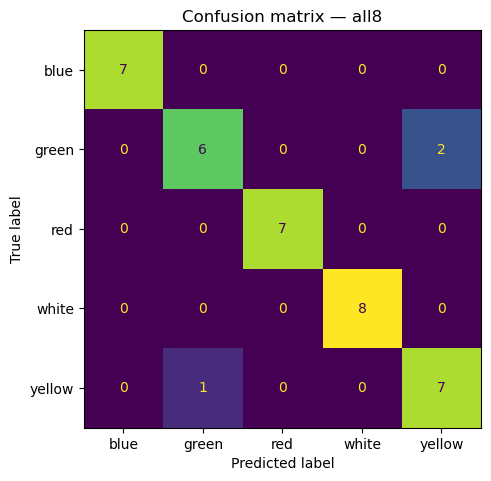


TEST EVAL — classic4  |  n_channels=4  |  checkpoint=best_classic4.pt
Test accuracy: 0.7368
Confusion matrix (rows=true, cols=pred):
[[5 0 0 2 0]
 [3 4 0 1 0]
 [0 0 7 0 0]
 [0 0 0 8 0]
 [0 0 3 1 4]]

Classification report:
              precision    recall  f1-score   support

        blue     0.6250    0.7143    0.6667         7
       green     1.0000    0.5000    0.6667         8
         red     0.7000    1.0000    0.8235         7
       white     0.6667    1.0000    0.8000         8
      yellow     1.0000    0.5000    0.6667         8

    accuracy                         0.7368        38
   macro avg     0.7983    0.7429    0.7247        38
weighted avg     0.8055    0.7368    0.7236        38



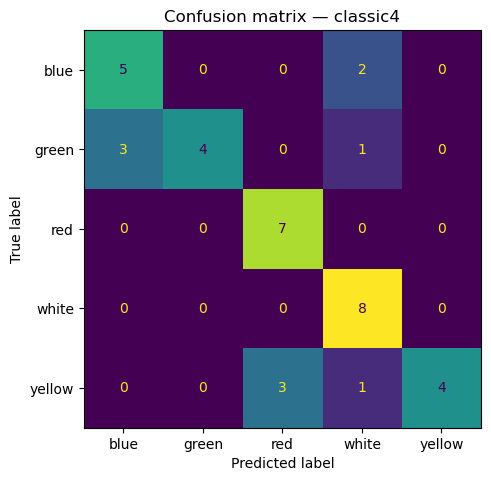


TEST EVAL — h2_4  |  n_channels=4  |  checkpoint=best_h2_4.pt
Test accuracy: 1.0000
Confusion matrix (rows=true, cols=pred):
[[7 0 0 0 0]
 [0 8 0 0 0]
 [0 0 7 0 0]
 [0 0 0 8 0]
 [0 0 0 0 8]]

Classification report:
              precision    recall  f1-score   support

        blue     1.0000    1.0000    1.0000         7
       green     1.0000    1.0000    1.0000         8
         red     1.0000    1.0000    1.0000         7
       white     1.0000    1.0000    1.0000         8
      yellow     1.0000    1.0000    1.0000         8

    accuracy                         1.0000        38
   macro avg     1.0000    1.0000    1.0000        38
weighted avg     1.0000    1.0000    1.0000        38



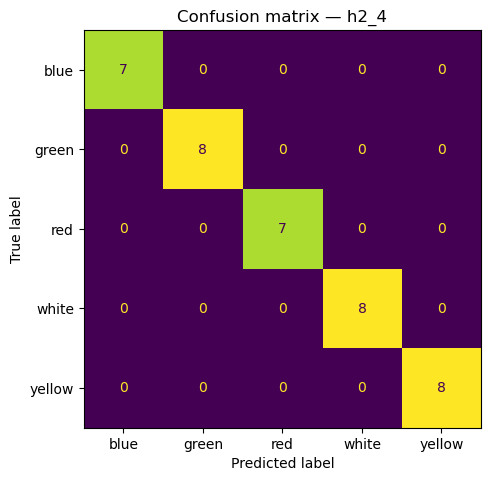


EVAL SUMMARY (in memory; saving happens in Block 9):


,run,n_channels,epochs,best_val_acc,test_acc,checkpoint
0,all8,8,10,0.973684,0.921053,best_all8.pt
1,classic4,4,10,0.894737,0.736842,best_classic4.pt
2,h2_4,4,10,1.000000,1.000000,best_h2_4.pt


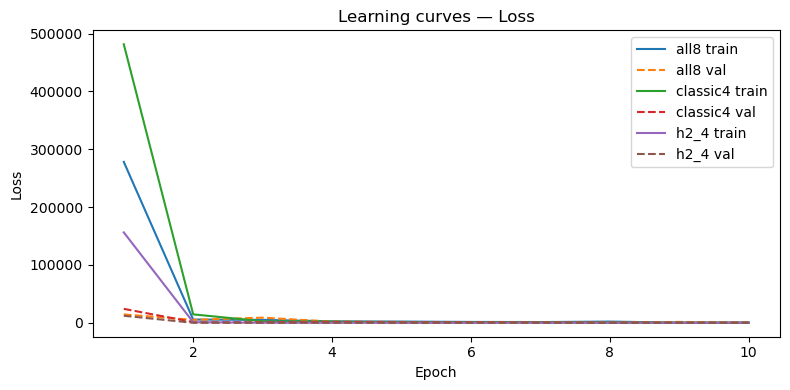

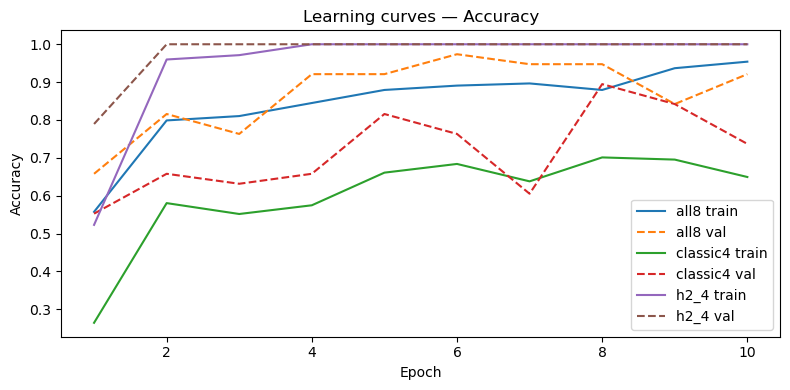

In [8]:
# Cell 8 — Evaluation + comparisons  

# run the model on a DataLoader and collect predictions 
@torch.no_grad()                                                                          # no gradients needed for evaluation
def predict_on_loader(model, dataloader):                                                 # function: get y_true + y_pred
    model.eval()                                                                          # set model to eval mode
    y_true_parts = []                                                                     # store true labels (chunks)
    y_pred_parts = []                                                                     # store predicted labels (chunks)
    for xb, yb in dataloader:                                                             # loop over minibatches
        xb = xb.to(torch.float32)                                                         # ensure float32 inputs
        logits, _ = model(xb)                                                             # forward pass (logits + latent)
        preds = torch.argmax(logits, dim=1)                                               # predicted class per sample
        y_true_parts.append(yb.cpu().numpy())                                             # collect true labels on CPU
        y_pred_parts.append(preds.cpu().numpy())                                          # collect predicted labels on CPU
    y_true = np.concatenate(y_true_parts, axis=0)                                         # stitch all batches into one array
    y_pred = np.concatenate(y_pred_parts, axis=0)                                         # stitch all batches into one array
    return y_true, y_pred                                                                 # return full-length arrays

# Runs to evaluate
run_order = ["all8", "classic4", "h2_4"]                                                   # consistent run order for prints/plots

# Containers to keep results in memory for saving
eval_rows = []                                                                            # list of dicts for a summary table later
conf_mats = {}                                                                            # dict: run_name -> confusion matrix
reports = {}                                                                              # dict: run_name -> text classification report

# Evaluate each group on the test set using its best checkpoint 
for run_name in run_order:                                                                # loop over your 3 groups
    keys_subset = channel_sets[run_name]                                                  # channel keys for this run
    dl_train, dl_val, dl_test, C_run = make_loaders_for_keys(keys_subset)                 # rebuild loaders for this run
    model, criterion, optimizer = make_model_and_trainers(in_channels=C_run, n_classes=n_classes)  # rebuild model skeleton
    ckpt_path = f"best_{run_name}.pt"                                                     # checkpoint file from Cell 7
    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))                      # load best weights into model

    y_true, y_pred = predict_on_loader(model, dl_test)                                    # get test predictions
    test_acc = float((y_true == y_pred).mean())                                           # compute test accuracy

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))                    # confusion matrix (int labels)
    conf_mats[run_name] = cm                                                              # store matrix for later use

    report_txt = classification_report(                                                   # per-class precision/recall/F1
        y_true,                                                                           # true labels
        y_pred,                                                                           # predicted labels
        labels=np.arange(n_classes),                                                      # ensure stable label order
        target_names=class_names,                                                         # show hue names
        digits=4,                                                                         # print 4 decimals
        zero_division=0                                                                   # avoid warnings if any class missing
    )
    reports[run_name] = report_txt                                                        # store report text for later use

    best_val_acc = float(np.max(all_histories[run_name]["val_acc"]))                      # best validation accuracy from training history
    eval_rows.append({                                                                    # store summary row (in memory)
        "run": run_name,                                                                  # run name
        "n_channels": int(C_run),                                                         # number of channels used
        "epochs": int(len(all_histories[run_name]["train_loss"])),                        # how many epochs were run
        "best_val_acc": best_val_acc,                                                     # best val accuracy
        "test_acc": test_acc,                                                             # final test accuracy
        "checkpoint": ckpt_path                                                           # checkpoint filename
    })

    print("\n" + "=" * 70)                                                                # separator
    print(f"TEST EVAL — {run_name}  |  n_channels={C_run}  |  checkpoint={ckpt_path}")     # header line
    print(f"Test accuracy: {test_acc:.4f}")                                               # test accuracy
    print("Confusion matrix (rows=true, cols=pred):")                                     # confusion matrix label
    print(cm)                                                                             # print confusion matrix
    print("\nClassification report:")                                                     # report label
    print(report_txt)                                                                     # print report

    fig, ax = plt.subplots(figsize=(5, 5))                                                # new figure for confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)        # build display object
    disp.plot(ax=ax, values_format="d", colorbar=False)                                   # draw matrix (counts)
    ax.set_title(f"Confusion matrix — {run_name}")                                        # title
    plt.tight_layout()                                                                    # tidy layout
    plt.show()                                                                            # show plot

# Make an in-memory summary table 
df_eval = pd.DataFrame(eval_rows).sort_values("run")                                      # build a DataFrame for inspection
print("\n" + "=" * 70)                                                                    # separator
print("EVAL SUMMARY (in memory; saving happens in Block 9):")                             # header
display(df_eval)                                                                          # show the table

# Plot learning curves (train/val loss and accuracy) for all runs on same axes 
epochs = np.arange(1, EPOCHS + 1)                                                         # epoch numbers (1..EPOCHS)

plt.figure(figsize=(8, 4))                                                                # figure for loss curves
for run_name in run_order:                                                                # loop over runs
    h = all_histories[run_name]                                                           # history dict for this run
    plt.plot(epochs, h["train_loss"], label=f"{run_name} train")                          # train loss line
    plt.plot(epochs, h["val_loss"],   linestyle="--", label=f"{run_name} val")            # val loss line (dashed)
plt.xlabel("Epoch")                                                                       # x label
plt.ylabel("Loss")                                                                        # y label
plt.title("Learning curves — Loss")                                                       # title
plt.legend()                                                                              # legend
plt.tight_layout()                                                                        # tidy layout
plt.show()                                                                                # show plot

plt.figure(figsize=(8, 4))                                                                # figure for accuracy curves
for run_name in run_order:                                                                # loop over runs
    h = all_histories[run_name]                                                           # history dict for this run
    plt.plot(epochs, h["train_acc"], label=f"{run_name} train")                           # train accuracy line
    plt.plot(epochs, h["val_acc"],   linestyle="--", label=f"{run_name} val")             # val accuracy line (dashed)
plt.xlabel("Epoch")                                                                       # x label
plt.ylabel("Accuracy")                                                                    # y label
plt.title("Learning curves — Accuracy")                                                   # title
plt.legend()                                                                              # legend
plt.tight_layout()                                                                        # tidy layout
plt.show()                                                                                # show plot


In [9]:
# Cell 9 — Save evaluation outputs (summary CSV + confusion matrices)  

assert "df_eval" in globals(), "df_eval not found. Run Cell 8 first."            # summary table from Cell 8
assert "conf_mats" in globals(), "conf_mats not found. Run Cell 8 first."        # confusion matrices dict from Cell 8
assert "class_names" in globals(), "class_names not found. Run Cell 3 first."    # label names from LabelEncoder
assert "run_order" in globals(), "run_order not found. Run Cell 8 first."        # run order list from Cell 8

# Output folder 
OUT_DIR = ZARR_PATH.parent / "cnn_eval_outputs"                      # folder next to dataset.zarr
OUT_DIR.mkdir(parents=True, exist_ok=True)                           # create folder if needed

# Save the summary table (CSV) 
summary_csv = OUT_DIR / "cnn_eval_summary.csv"                       # output CSV path
df_eval.to_csv(summary_csv, index=False)                             # write summary table
print("Saved summary CSV:", summary_csv)                             # confirm save

# Save confusion matrices -
cm_dir = OUT_DIR / "confusion_matrices"                              # subfolder for confusion matrices
cm_dir.mkdir(parents=True, exist_ok=True)                            # create subfolder

combined = {}                                                        # store all confusion matrices in one file too
for run_name in run_order:                                           # loop in consistent order
    cm = np.asarray(conf_mats[run_name], dtype=int)                  # ensure plain int array
    cm_obj = {                                                       # JSON-friendly object
        "run": run_name,                                             # run name
        "class_names": list(class_names),                            # label names in matrix order
        "confusion_matrix": cm.tolist()                              # matrix as nested Python lists
    }
    combined[run_name] = cm_obj                                      # store in combined dict

    cm_path = cm_dir / f"confusion_matrix_{run_name}.json"           # per-run JSON path
    with open(cm_path, "w") as f:                                    # open file for writing
        json.dump(cm_obj, f, indent=2)                               # save pretty JSON
    print("Saved confusion matrix JSON:", cm_path)                   # confirm save

combined_path = cm_dir / "confusion_matrices_all_runs.json"          # combined JSON path
with open(combined_path, "w") as f:                                  # open file for writing
    json.dump(combined, f, indent=2)                                 # save all runs together
print("Saved combined confusion matrices JSON:", combined_path)      # confirm save

# 3) Save a copy of the label mapping (int, hue)
label_map = {int(i): str(name) for i, name in enumerate(class_names)}  # encoder mapping
label_map_path = OUT_DIR / "label_mapping.json"                        # mapping file path
with open(label_map_path, "w") as f:                                   # open file
    json.dump(label_map, f, indent=2)                                  # save mapping
print("Saved label mapping JSON:", label_map_path)                     # confirm save

# 4) Print a quick directory listing
print("\nWrote files:")                                               # header
for p in sorted(OUT_DIR.rglob("*")):                                   # walk output folder
    if p.is_file():                                                    # only print files
        print(" -", p)                                                 # show saved file paths


Saved summary CSV: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs/cnn_eval_summary.csv
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs/confusion_matrices/confusion_matrix_all8.json
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs/confusion_matrices/confusion_matrix_classic4.json
Saved confusion matrix JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs/confusion_matrices/confusion_matrix_h2_4.json
Saved combined confusion matrices JSON: /Users/kate/Documents/retina-model/notebooks/AllHues1_20260115_201857/export_retina_20260119_105329/cnn_eval_outputs/confusion_matrices/confusion_matrices_all_runs.json
Saved label mapping JSON: /Users/kate/Documents/retina